#MOUNTS/IMPORTS

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install pysam
import pysam
import pandas as pd
import os
!apt-get update -qq
!apt-get install -y bcftools tabix
!pip install pysam
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import subprocess
import time
import tracemalloc


vcf_path = "/content/drive/MyDrive/1000Genome/eval_pairs/HG00581_HG00635_merged.vcf.gz" #specify the unphased VCF file you want here (you can find our data in github, but this can be run on any VCF)
vcf_path_tbi = "/content/drive/MyDrive/1000Genome/eval_pairs/HG00581_HG00635_merged.vcf.gz.tbi"


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 60.6 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libhts3 libhtscodecs2
Suggested packages:
  python3-numpy python3-matplotlib texlive-latex-recommended
The following NEW packages will be installed:
  bcftools libhts3 libhtscodecs2 tabix
0 upgraded, 4 newly installed, 0 to remove and 118 not upgraded.
Need to get 1,491 kB of archives.
After this operation, 4,626 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhtscodecs2 amd64 1.1.1-3 [53.2 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhts3 amd64 1.13+ds-2build1 [390 kB]


#Calculate IBD segments between two individuals

you are able to pick the number of chromosomes to run it on. You can run it on all, or just a subset.

In [2]:
"""
PARAMETERS
"""

sample1 = "HG00581" #specify which two samples you want to look at from the vcf you picked
sample2 = "HG00635"

MIN_AF = 0.05 # remove rare alleles
BLOCK_SIZE = 1000 # How many SNPS do we look at at once
SMOOTH = 0.01 # Prevents IBD2 having a 0 probability
EPS = 1e-300 # log probabilities, so need to add tiny amount to avoid log(0) (disaster)

CHROMS = [21,22] # "all" or [1] or [13,14]. we recommend using [21,22] if you want it to run in under 10. You are welcome to use "all" but it will likely take over an hour

SMOOTH_WINDOW = 10
THR0 = 0.40 #lower number means you make it more likely for this IBD to occur in the final state
THR1 = 0.80
THR2 = 0.60


"""
Helpers

"""

chrom_size_d = {"1": 249250621,"2": 243199373, "3": 198022430, "4": 191154276, "5": 180915260, "6": 171115067,"7":
159138663,"8": 146364022,"9": 141213431,"10": 135534747, "11": 135006516,"12": 133851895,"13": 115169878,"14": 107349540,
"15": 102531392,"16": 90354753,"17": 81195210,"18": 78077248,"19": 59128983,"20": 63025520,"21": 48129895,"22": 51304566}

def chrom_num(c):
  c = str(c)
  if c.startswith("chr"):
    c = c[3:]
  return int(c)

def use_this_chrom(c):
  c = chrom_num(c)

  if c < 1 or c > 22:
    return False

  if CHROMS == "all":
    return True

  if c in CHROMS:
    return True

  return False

def is_ba(rec): #for our purposes, we only consider SNPS with two options (ignore multi bp snps)
  if rec.alts != None:
    alts = rec.alts
  else:
    alts = ()

  if len(alts) != 1 or len(rec.ref) != 1 or len(alts[0]) != 1:
    return False
  return True


def get_af(snp):
  af = snp.info.get("AF")

  if af == None:
    return None
  else:
    return af[0]

def ibs_class(a, b):
    if a is None:
        return None
    if b is None:
        return None
    if None in a:
        return None
    if None in b:
        return None

    new_a = tuple(sorted(a)) #could be 0,1 or 1,0 so gotta line them up
    new_b = tuple(sorted(b))

    if new_a == new_b:
        return 2



    elif new_a == (0, 0) and new_b == (1, 1):
        return 0

    if new_a == (1, 1) and new_b == (0, 0):
        return 0
    else:
        return 1
def probability(af):
  af_squared = af*af
  af_four = af_squared*af_squared


  non_af = 1 - af
  non_af_squared = non_af * non_af
  non_af_four = non_af_squared * non_af_squared


  zero_given_0 = 2 * non_af_squared * af_squared
  two_given_0 = non_af_four + (4 * af_squared * non_af_squared) + af_four
  one_given_0 = 1 - zero_given_0 - two_given_0

  ibd0 = np.array([zero_given_0, one_given_0, two_given_0], dtype=float)

  one_given_1 = 2 * af * non_af
  two_given_1 = af_squared + non_af_squared
  ibd1 = np.array([SMOOTH, one_given_1, two_given_1], dtype=float)
  ibd1 = ibd1 / ibd1.sum() #normalize


  ibd2 = np.array([SMOOTH, SMOOTH, 1.0], dtype=float)
  ibd2 = ibd2 / ibd2.sum() #normalize

  return ibd0,ibd1,ibd2

def window_smooth(states, chroms, window, thr0=0.50, thr1=0.80, thr2=0.80): #if we find a window with enough of one state, make it that state
    s = np.asarray(states, dtype=int)
    out = s.copy()
    n = len(s)

    for i in range(0, n - window + 1):

        same_chrom = True
        for j in range(i, i + window - 1):
            if chroms[j] != chroms[j + 1]:
                same_chrom = False
                break

        if not same_chrom:
            continue

        w = s[i:i+window]

        f0 = np.mean(w == 0)
        f1 = np.mean(w == 1)
        f2 = np.mean(w == 2)

        if f0 > thr0:

            out[i:i+window] = 0
            continue

        if f1 >= thr1:

            out[i:i+window] = 1
            continue

        if f2 >= thr2:

            out[i:i+window] = 2
            continue
    return out


vcf = pysam.VariantFile(vcf_path)

rows = []
for snp in vcf:
    if not use_this_chrom(snp.chrom):
        continue

    if not is_ba(snp):
        continue
    af = get_af(snp)
    if af == None:
        continue

    if af > 0.5:
        af = 1.0 - af #always want af less than 50%
    if af < MIN_AF:
        continue

    s1 = snp.samples.get(sample1)
    s2 = snp.samples.get(sample2)

    if s1 is None:
        continue
    if s2 is None: #only want to use snps that have been recorded for both
        continue

    gt1 = s1.get("GT")
    gt2 = s2.get("GT")
    obs = ibs_class(gt1, gt2)
    if obs == None:
        continue

    chrom = str(snp.chrom)
    if chrom.startswith("chr"):
        chrom = chrom[3:]

    pos = int(snp.pos)
    to_append = (chrom, pos, af, obs)
    rows.append(to_append)
df = pd.DataFrame(rows, columns=["chrom", "pos", "maf", "ibs_obs"]) #converting to dataframe definitely loses speed, but as datascientist, feel more comfortable in df and feel like I can explain the code better that way. Future direction = pick more efficient data structure

df["chrom_num"] = df["chrom"].map(chrom_num)
df = df.sort_values(["chrom_num", "pos"]).reset_index(drop=True)

n = len(df)

number_blocks = (n + BLOCK_SIZE-1) // BLOCK_SIZE

states = np.zeros(number_blocks, dtype=int)
chroms = []
pos = []


for block in range(number_blocks):
  s = block * BLOCK_SIZE
  end = (block + 1) * BLOCK_SIZE
  if end > n:
    end = n
  block_to_cons = df.iloc[s:end]
  first_row = block_to_cons.iloc[0]
  chroms.append(first_row["chrom"])
  pos.append(int(first_row["pos"]))
  log0 = 0.0
  log1 = 0.0
  log2 = 0.0

  for i in range(len(block_to_cons)):
        row = block_to_cons.iloc[i]
        p = float(row["maf"])
        obs = int(row["ibs_obs"])

        ibd0, ibd1, ibd2 = probability(p)
        log0 += np.log(max(ibd0[obs], EPS))
        log1 += np.log(max(ibd1[obs], EPS))
        log2 += np.log(max(ibd2[obs], EPS))
  best = np.argmax([log0, log1, log2])
  states[block] = best

smoothed = window_smooth(states, chroms, SMOOTH_WINDOW, THR0, THR1, THR2)
smoothed = np.asarray(smoothed, dtype=int)

# map from blocks back to BPs

df2 = df.copy().reset_index(drop=True)
df2["snp_idx"] = np.arange(len(df2))
df2["block"] = (df2["snp_idx"] // BLOCK_SIZE).astype(int)
df2["ibd_state"] = smoothed[df2["block"].values]

blocks = df2.groupby(["chrom", "block"]).agg(start_pos=("pos", "first"), end_pos=("pos", "last"),ibd_state=("ibd_state", "first")).reset_index()
blocks["bp_span"] = blocks["end_pos"] - blocks["start_pos"]

segment_rows = []

for chrom in sorted(blocks["chrom"].unique(), key=chrom_num):
    chrom_blocks = blocks[blocks["chrom"] == chrom].reset_index(drop=True)

    if len(chrom_blocks) == 0:
        continue

    curr_ibd = int(chrom_blocks.loc[0, "ibd_state"])
    curr_start = int(chrom_blocks.loc[0, "start_pos"])
    curr_end = int(chrom_blocks.loc[0, "end_pos"])

    for i in range(1, len(chrom_blocks)):
        row = chrom_blocks.loc[i]
        state = int(row["ibd_state"])
        start = int(row["start_pos"])
        end = int(row["end_pos"])

        if state == curr_ibd:
            curr_end = end
        else:
            segment_rows.append((chrom, curr_start, curr_end, "IBD" + str(curr_ibd)))
            curr_ibd = state
            curr_start = start
            curr_end = end

    segment_rows.append((chrom, curr_start, curr_end, "IBD" + str(curr_ibd)))

segments_df = pd.DataFrame(segment_rows, columns=["chrom", "start", "end", "IBD"])

for chrom in segments_df["chrom"].unique(): #make sure IBDs start and end at beginning (0) and end (chrome_size_d[chrom_num])
    chrom_rows = segments_df["chrom"] == chrom
    chrom_idx = segments_df.index[chrom_rows]

    if len(chrom_idx) == 0:
        continue

    first_idx = chrom_idx[0]
    last_idx = chrom_idx[-1]

    segments_df.loc[first_idx, "start"] = 0
    segments_df.loc[last_idx, "end"] = chrom_size_d[str(chrom)]



#Segment Outputs + Visual Representation

  chrom     start       end   IBD
0    21         0  15456997  IBD1
1    21  15457003  21816578  IBD0
2    21  21816786  24101870  IBD1
3    21  24102779  48129895  IBD0
4    22         0  16867938  IBD0
5    22  16867958  17785825  IBD2
6    22  17785838  42933315  IBD1
7    22  42933371  51304566  IBD2
Percent of chromosome in each IBD:
chr21:
  IBD0: 63.14%
  IBD1: 36.86%
  IBD2: 0.00%
chr22:
  IBD0: 32.88%
  IBD1: 49.02%
  IBD2: 18.11%


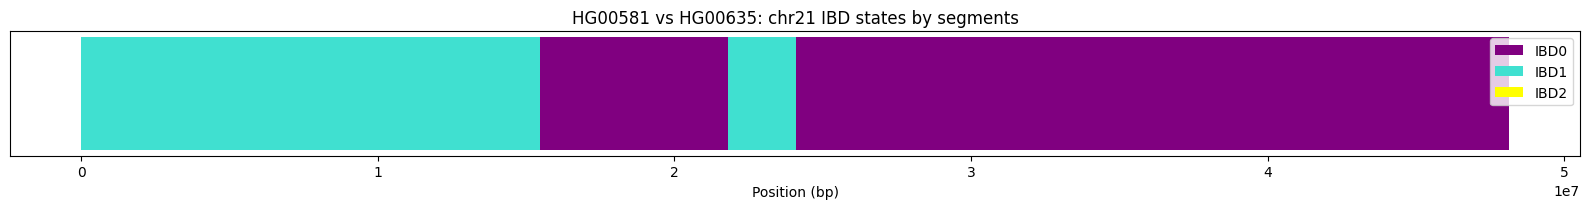

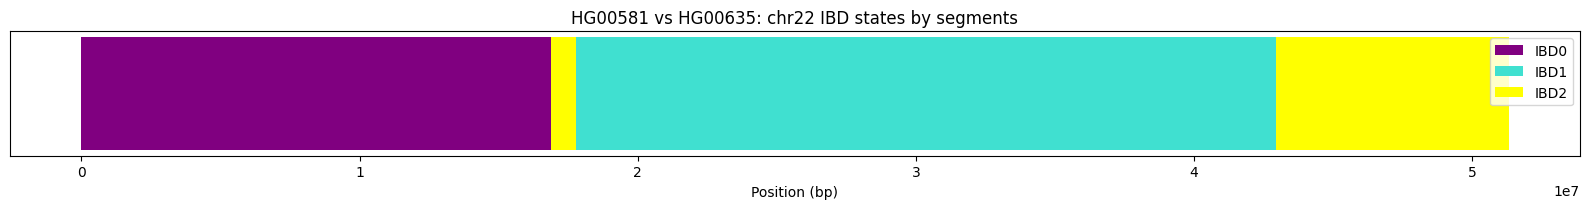

In [3]:
# used GPT to help generate final printing of results and graphs to ensure
# best possible formatting
print(segments_df)

colors = {"IBD0": "purple", "IBD1": "turquoise", "IBD2": "yellow"}

print("Percent of chromosome in each IBD:")
for chrom in sorted(segments_df["chrom"].unique(), key=chrom_num):
    chrom_segments = segments_df[segments_df["chrom"] == chrom].reset_index(drop=True)

    chrom_segments["bp_span"] = chrom_segments["end"] - chrom_segments["start"]

    bp_by_state = chrom_segments.groupby("IBD")["bp_span"].sum()
    bp_total = bp_by_state.sum()
    pct_by_state = (100 * bp_by_state) / bp_total

    print(f"chr{chrom}:")
    for k in ("IBD0", "IBD1", "IBD2"):
        pct = float(pct_by_state.get(k, 0.0))
        print(f"  {k}: {pct:.2f}%")

for chrom in sorted(segments_df["chrom"].unique(), key=chrom_num):
    chrom_segments = segments_df[segments_df["chrom"] == chrom].reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(16, 2.2))

    for _, r in chrom_segments.iterrows():
        x0 = float(r["start"])
        w = float(r["end"] - r["start"])
        if w < 1:
            w = 1
        ax.broken_barh([(x0, w)], (0, 1), facecolors=[colors[r["IBD"]]])

    ax.set_yticks([])
    ax.set_xlabel("Position (bp)")
    ax.set_title(f"{sample1} vs {sample2}: chr{chrom} IBD states by segments")

    legend_elements = [
        Patch(facecolor="purple", label="IBD0"),
        Patch(facecolor="turquoise", label="IBD1"),
        Patch(facecolor="yellow", label="IBD2"),
    ]
    ax.legend(handles=legend_elements, loc="upper right")

    plt.tight_layout()
    plt.show()